In [1]:
# ========================================
# SETUP ENVIRONMENT
# ========================================
import os
import sys

# Set Java (SỬA PATH NÀY!)
os.environ['JAVA_HOME'] = 'C:\\Java\\jdk-1.8'

# QUAN TRỌNG: Bypass Hadoop requirement
os.environ['HADOOP_HOME'] = os.environ.get('JAVA_HOME')
os.environ['PATH'] = f"{os.environ['JAVA_HOME']}\\bin;{os.environ.get('PATH', '')}"

print(f"✅ JAVA_HOME: {os.environ['JAVA_HOME']}")

✅ JAVA_HOME: C:\Java\jdk-1.8


In [2]:
# ========================================
# INSTALL PACKAGES
# ========================================
!pip install pyspark findspark matplotlib seaborn -q


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ========================================
# IMPORT LIBRARIES
# ========================================
import findspark
findspark.init()

from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style cho plots
plt.style.use('default')
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


In [4]:
# ========================================
# INITIALIZE SPARK SESSION
# ========================================
import tempfile

spark = SparkSession.builder \
    .appName("YouTubeCategoryAnalysis") \
    .master("local[1]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.warehouse.dir", tempfile.gettempdir()) \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} started")

✅ Spark 3.3.1 started


In [5]:
# ========================================
# LOAD PREPROCESSED DATA
# ========================================
df = spark.read.csv("./data/preprocessed_data.csv", header=True, inferSchema=True)

print(f"📊 Loaded {df.count():,} rows with {len(df.columns)} columns")
print("\n=== SAMPLE DATA ===")
df.show(5)

📊 Loaded 268,787 rows with 13 columns

=== SAMPLE DATA ===
+-----------+--------------------+-------------------+--------------------+-------------+----------+-------------------+--------------------+----------+------+--------+-------------+--------------------+
|   video_id|               title|        publishedAt|           channelId| channelTitle|categoryId|      trending_date|                tags|view_count| likes|dislikes|comment_count|         description|
+-----------+--------------------+-------------------+--------------------+-------------+----------+-------------------+--------------------+----------+------+--------+-------------+--------------------+
|3C66w5Z0ixs|I ASKED HER TO BE...|2020-08-11 19:20:14|UCvtRTOMP2TqYqu51...|     Brawadis|        22|2020-08-12 00:00:00|brawadis|prank|ba...|   1514614|156908|    5855|        35313|SUBSCRIBE to BRAW...|
|M9Pmf9AB4Mo|Apex Legends | St...|2020-08-11 17:00:10|UC0ZV6M2THA81QT9h...| Apex Legends|        20|2020-08-12 00:00:00|Apex 

In [6]:
# ========================================
# CATEGORY OVERVIEW & MAPPING
# ========================================

# Tạo mapping categoryId sang tên category
df = df.withColumn("category_name", 
    when(col("categoryId") == "1", "Film & Animation")
    .when(col("categoryId") == "2", "Autos & Vehicles")
    .when(col("categoryId") == "10", "Music")
    .when(col("categoryId") == "15", "Pets & Animals")
    .when(col("categoryId") == "17", "Sports")
    .when(col("categoryId") == "19", "Travel & Events")
    .when(col("categoryId") == "20", "Gaming")
    .when(col("categoryId") == "22", "People & Blogs")
    .when(col("categoryId") == "23", "Comedy")
    .when(col("categoryId") == "24", "Entertainment")
    .when(col("categoryId") == "25", "News & Politics")
    .when(col("categoryId") == "26", "Howto & Style")
    .when(col("categoryId") == "27", "Education")
    .when(col("categoryId") == "28", "Science & Technology")
    .otherwise("Unknown")
)

print("=== CATEGORIES IN DATASET ===")
df.select("categoryId", "category_name").distinct().orderBy("categoryId").show()

total_categories = df.select("categoryId").distinct().count()
print(f"\n📋 Total categories: {total_categories}")

=== CATEGORIES IN DATASET ===
+----------+--------------------+
|categoryId|       category_name|
+----------+--------------------+
|         1|    Film & Animation|
|         2|    Autos & Vehicles|
|        10|               Music|
|        15|      Pets & Animals|
|        17|              Sports|
|        19|     Travel & Events|
|        20|              Gaming|
|        22|      People & Blogs|
|        23|              Comedy|
|        24|       Entertainment|
|        25|     News & Politics|
|        26|       Howto & Style|
|        27|           Education|
|        28|Science & Technology|
|        29|             Unknown|
+----------+--------------------+


📋 Total categories: 15


=== TOP CATEGORIES BY VIDEO COUNT ===
+----------+--------------------+-----+
|categoryId|       category_name|count|
+----------+--------------------+-----+
|        24|       Entertainment|53934|
|        20|              Gaming|53242|
|        10|               Music|43398|
|        17|              Sports|31327|
|        22|      People & Blogs|22653|
|        23|              Comedy|13183|
|         1|    Film & Animation|10923|
|        25|     News & Politics| 9669|
|        28|Science & Technology| 8156|
|        26|       Howto & Style| 7100|
|        27|           Education| 6655|
|         2|    Autos & Vehicles| 5492|
|        19|     Travel & Events| 1713|
|        15|      Pets & Animals| 1222|
|        29|             Unknown|  120|
+----------+--------------------+-----+



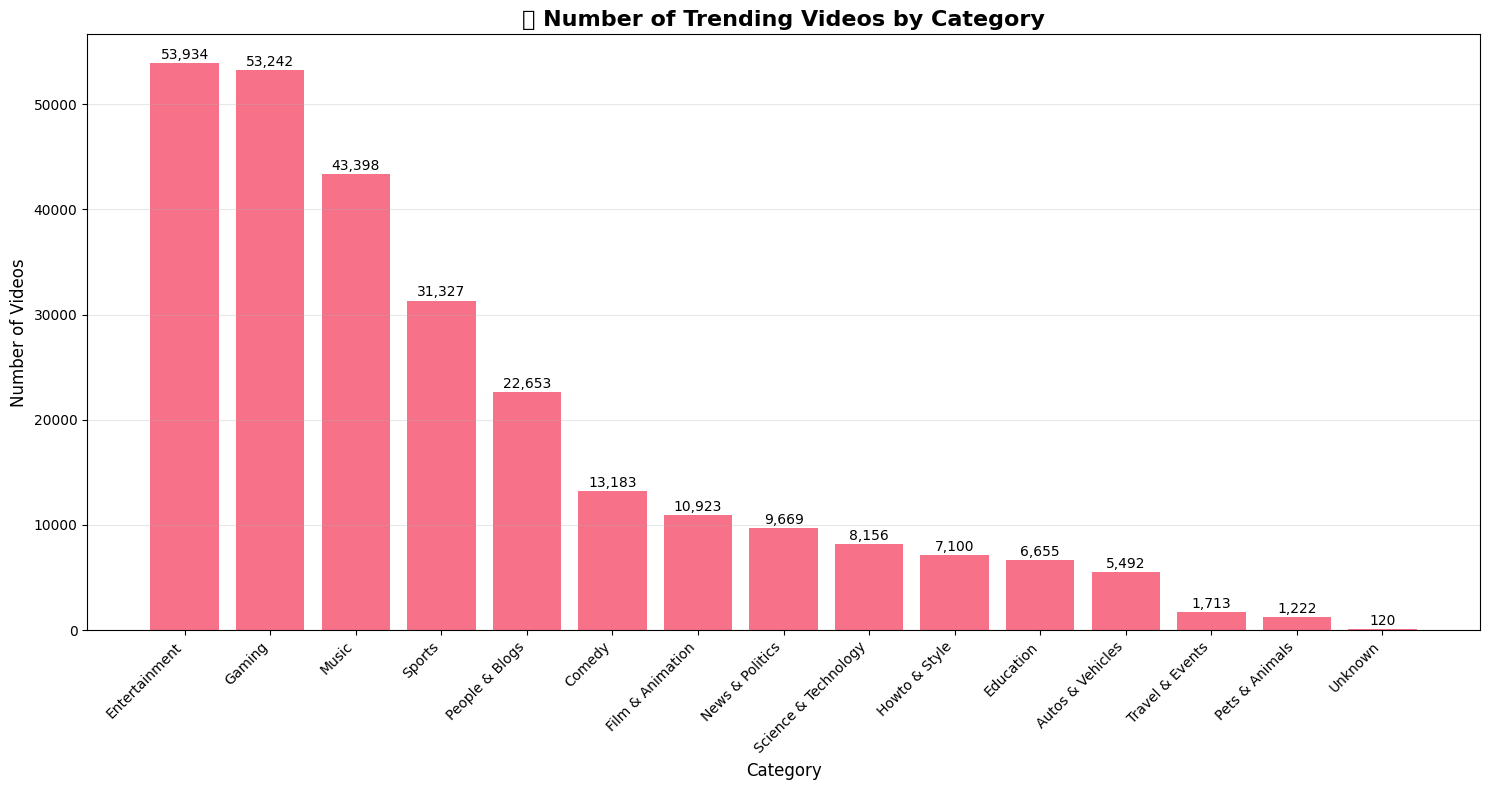


=== PERCENTAGE BREAKDOWN ===
Entertainment: 53,934 videos (20.07%)
Gaming: 53,242 videos (19.81%)
Music: 43,398 videos (16.15%)
Sports: 31,327 videos (11.65%)
People & Blogs: 22,653 videos (8.43%)


In [7]:
# ========================================
# PHÂN TÍCH 1: CATEGORY PHỔ BIẾN NHẤT
# ========================================

# Đếm số video theo category
category_counts = df.groupBy("categoryId", "category_name") \
    .count() \
    .orderBy(desc("count"))

print("=== TOP CATEGORIES BY VIDEO COUNT ===")
category_counts.show()

# Convert to Pandas for plotting
category_counts_pd = category_counts.toPandas()

# Plot
plt.figure(figsize=(15, 8))
bars = plt.bar(category_counts_pd['category_name'], category_counts_pd['count'])
plt.title('📊 Number of Trending Videos by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Videos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Percentage breakdown
total_videos = category_counts_pd['count'].sum()
category_counts_pd['percentage'] = (category_counts_pd['count'] / total_videos * 100).round(2)

print("\n=== PERCENTAGE BREAKDOWN ===")
for _, row in category_counts_pd.head(5).iterrows():
    print(f"{row['category_name']}: {row['count']:,} videos ({row['percentage']}%)")

=== TOTAL VIEWS BY CATEGORY ===
+----------+--------------------+-----------+
|categoryId|       category_name|total_views|
+----------+--------------------+-----------+
|        10|               Music|36135478030|
|        24|       Entertainment|32978966841|
|        20|              Gaming|16461396290|
|        17|              Sports|10131820707|
|        22|      People & Blogs| 7967143589|
|         1|    Film & Animation| 5661302348|
|        28|Science & Technology| 4234976127|
|        23|              Comedy| 3930707973|
|        25|     News & Politics| 2501592281|
|        27|           Education| 2202271108|
|        26|       Howto & Style| 1837086748|
|         2|    Autos & Vehicles| 1091422333|
|        15|      Pets & Animals|  340573469|
|        19|     Travel & Events|  333692813|
|        29|             Unknown|   38732903|
+----------+--------------------+-----------+



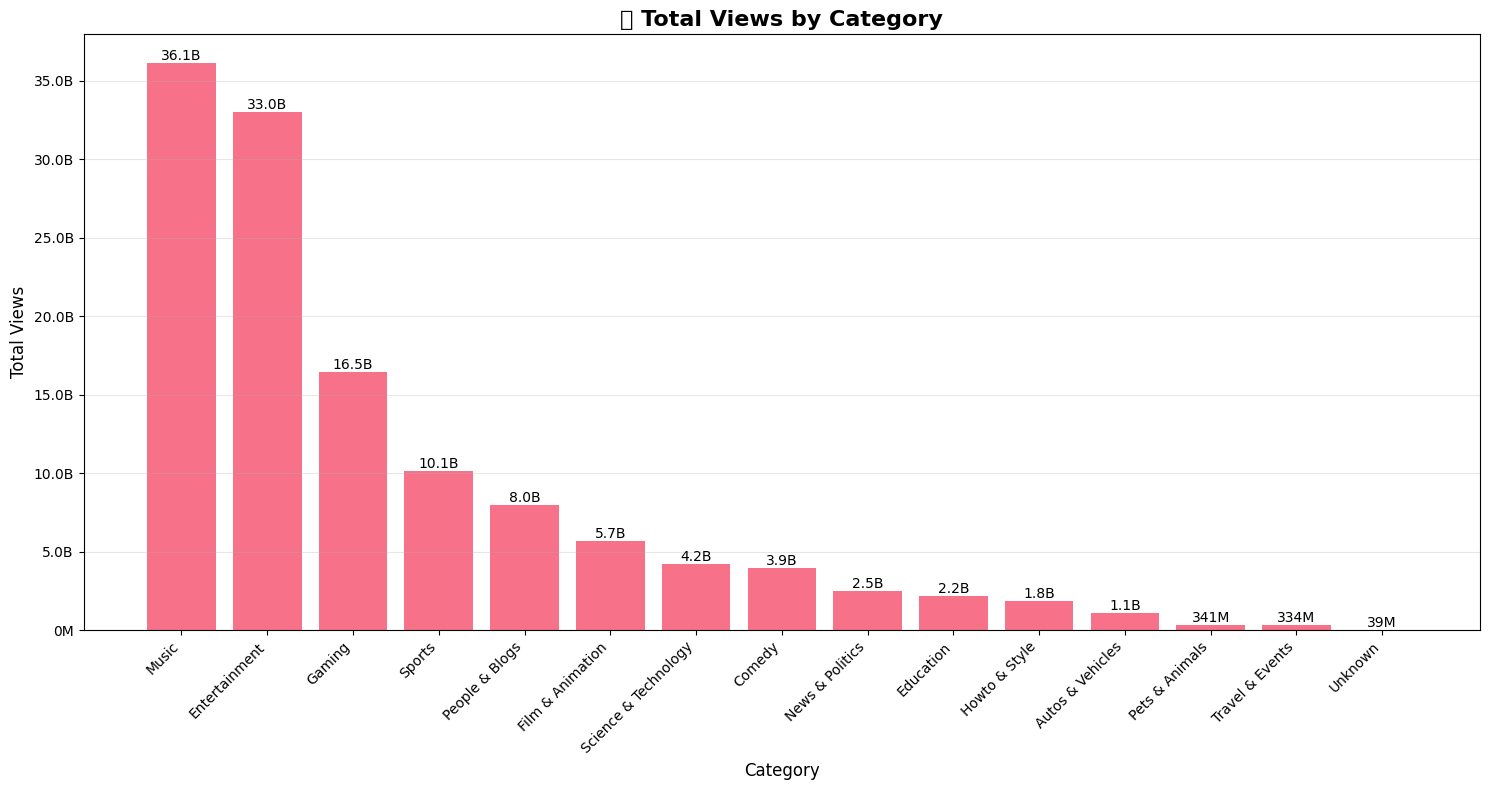

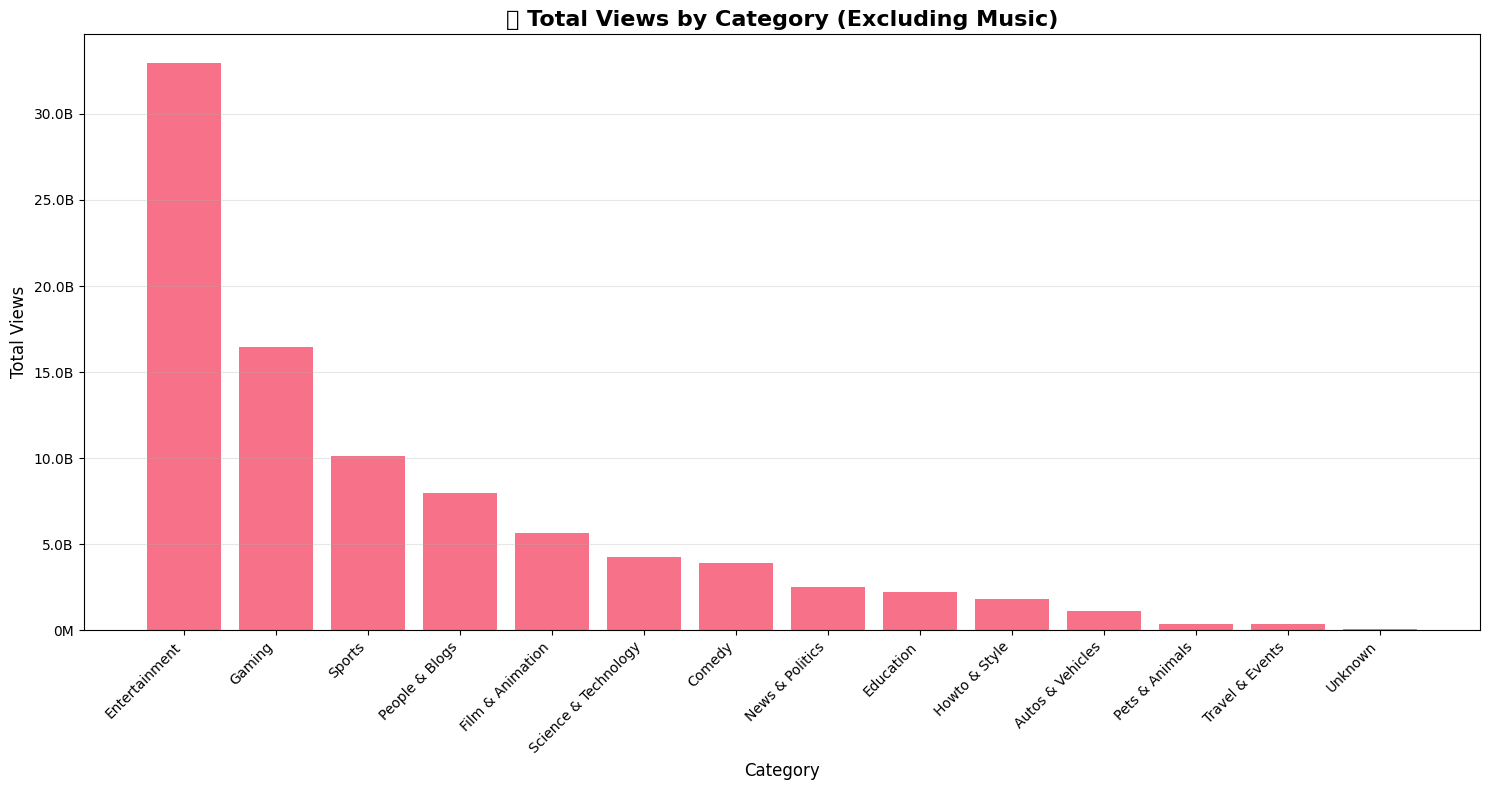

In [8]:
# ========================================
# PHÂN TÍCH 2: CATEGORY CÓ TỔNG VIEW CAO NHẤT
# ========================================

# Convert view_count to numeric
df = df.withColumn("view_count_num", col("view_count").cast("long"))

# Lấy view cao nhất cho mỗi video (để tránh duplicate)
window_spec = Window.partitionBy("video_id").orderBy(desc("view_count_num"))
df_unique = df.withColumn("rank", row_number().over(window_spec)) \
    .filter(col("rank") == 1) \
    .drop("rank")

# Tính tổng views theo category
total_views_by_category = df_unique.groupBy("categoryId", "category_name") \
    .agg(sum("view_count_num").alias("total_views")) \
    .orderBy(desc("total_views"))

print("=== TOTAL VIEWS BY CATEGORY ===")
total_views_by_category.show()

# Convert to Pandas for plotting
views_pd = total_views_by_category.toPandas()

# Plot 1: All categories
plt.figure(figsize=(15, 8))
bars = plt.bar(views_pd['category_name'], views_pd['total_views'])
plt.title('👁️ Total Views by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Views', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Format y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

# Add value labels
for bar in bars:
    height = bar.get_height()
    if height >= 1e9:
        label = f'{height/1e9:.1f}B'
    else:
        label = f'{height/1e6:.0f}M'
    plt.text(bar.get_x() + bar.get_width()/2., height,
             label, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Plot 2: Without Music (để thấy rõ các category khác)
views_no_music = views_pd[views_pd['category_name'] != 'Music']

plt.figure(figsize=(15, 8))
bars = plt.bar(views_no_music['category_name'], views_no_music['total_views'])
plt.title('👁️ Total Views by Category (Excluding Music)', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Views', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Format y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

=== UNIQUE CHANNELS BY CATEGORY ===
+----------+--------------------+---------------+
|categoryId|       category_name|unique_channels|
+----------+--------------------+---------------+
|        24|       Entertainment|           1783|
|        10|               Music|           1774|
|        20|              Gaming|           1729|
|        22|      People & Blogs|           1113|
|        17|              Sports|            695|
|        23|              Comedy|            397|
|         1|    Film & Animation|            389|
|        25|     News & Politics|            381|
|        26|       Howto & Style|            248|
|        28|Science & Technology|            231|
|        27|           Education|            194|
|         2|    Autos & Vehicles|            175|
|        19|     Travel & Events|             55|
|        15|      Pets & Animals|             43|
|        29|             Unknown|             14|
+----------+--------------------+---------------+



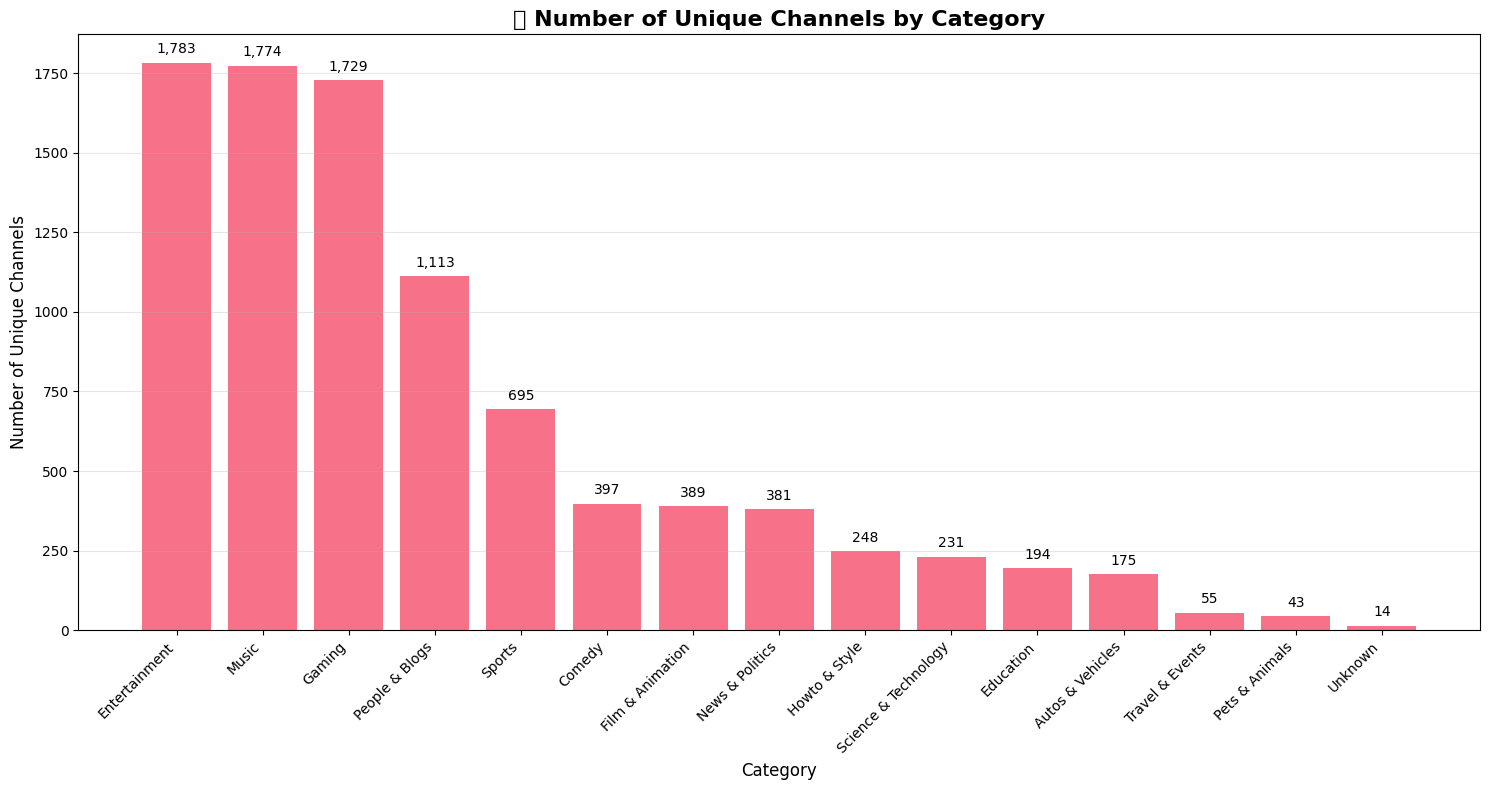

In [9]:
# ========================================
# PHÂN TÍCH 3: CATEGORY CÓ NHIỀU CHANNEL NHẤT
# ========================================

# Đếm số channel unique theo category
channels_by_category = df.groupBy("categoryId", "category_name") \
    .agg(countDistinct("channelTitle").alias("unique_channels")) \
    .orderBy(desc("unique_channels"))

print("=== UNIQUE CHANNELS BY CATEGORY ===")
channels_by_category.show()

# Convert to Pandas for plotting
channels_pd = channels_by_category.toPandas()

# Plot
plt.figure(figsize=(15, 8))
bars = plt.bar(channels_pd['category_name'], channels_pd['unique_channels'])
plt.title('👥 Number of Unique Channels by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Unique Channels', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

=== AVERAGE ENGAGEMENT BY CATEGORY ===
+----------+--------------------+------------------+------------------+------------------+------------------+
|categoryId|       category_name|         avg_likes|      avg_dislikes|      avg_comments|         avg_views|
+----------+--------------------+------------------+------------------+------------------+------------------+
|        10|               Music| 270698.7095718697|2442.5741739250657| 27959.66480022121| 4331114.000691276|
|        24|       Entertainment|189002.12316905847|1159.7402566099306|10061.876441576742| 4437457.209329922|
|        23|              Comedy|107829.10445270424| 847.6540241219752| 5617.740499127664|1590980.3785177881|
|        29|             Unknown|106977.88333333333|             941.4| 7394.558333333333|2333090.6166666667|
|        28|Science & Technology|105724.47903384012|1145.5516184404119|  5737.44151544875| 2753953.438818048|
|         1|    Film & Animation|103402.76755470109| 612.1617687448503| 7310.0452

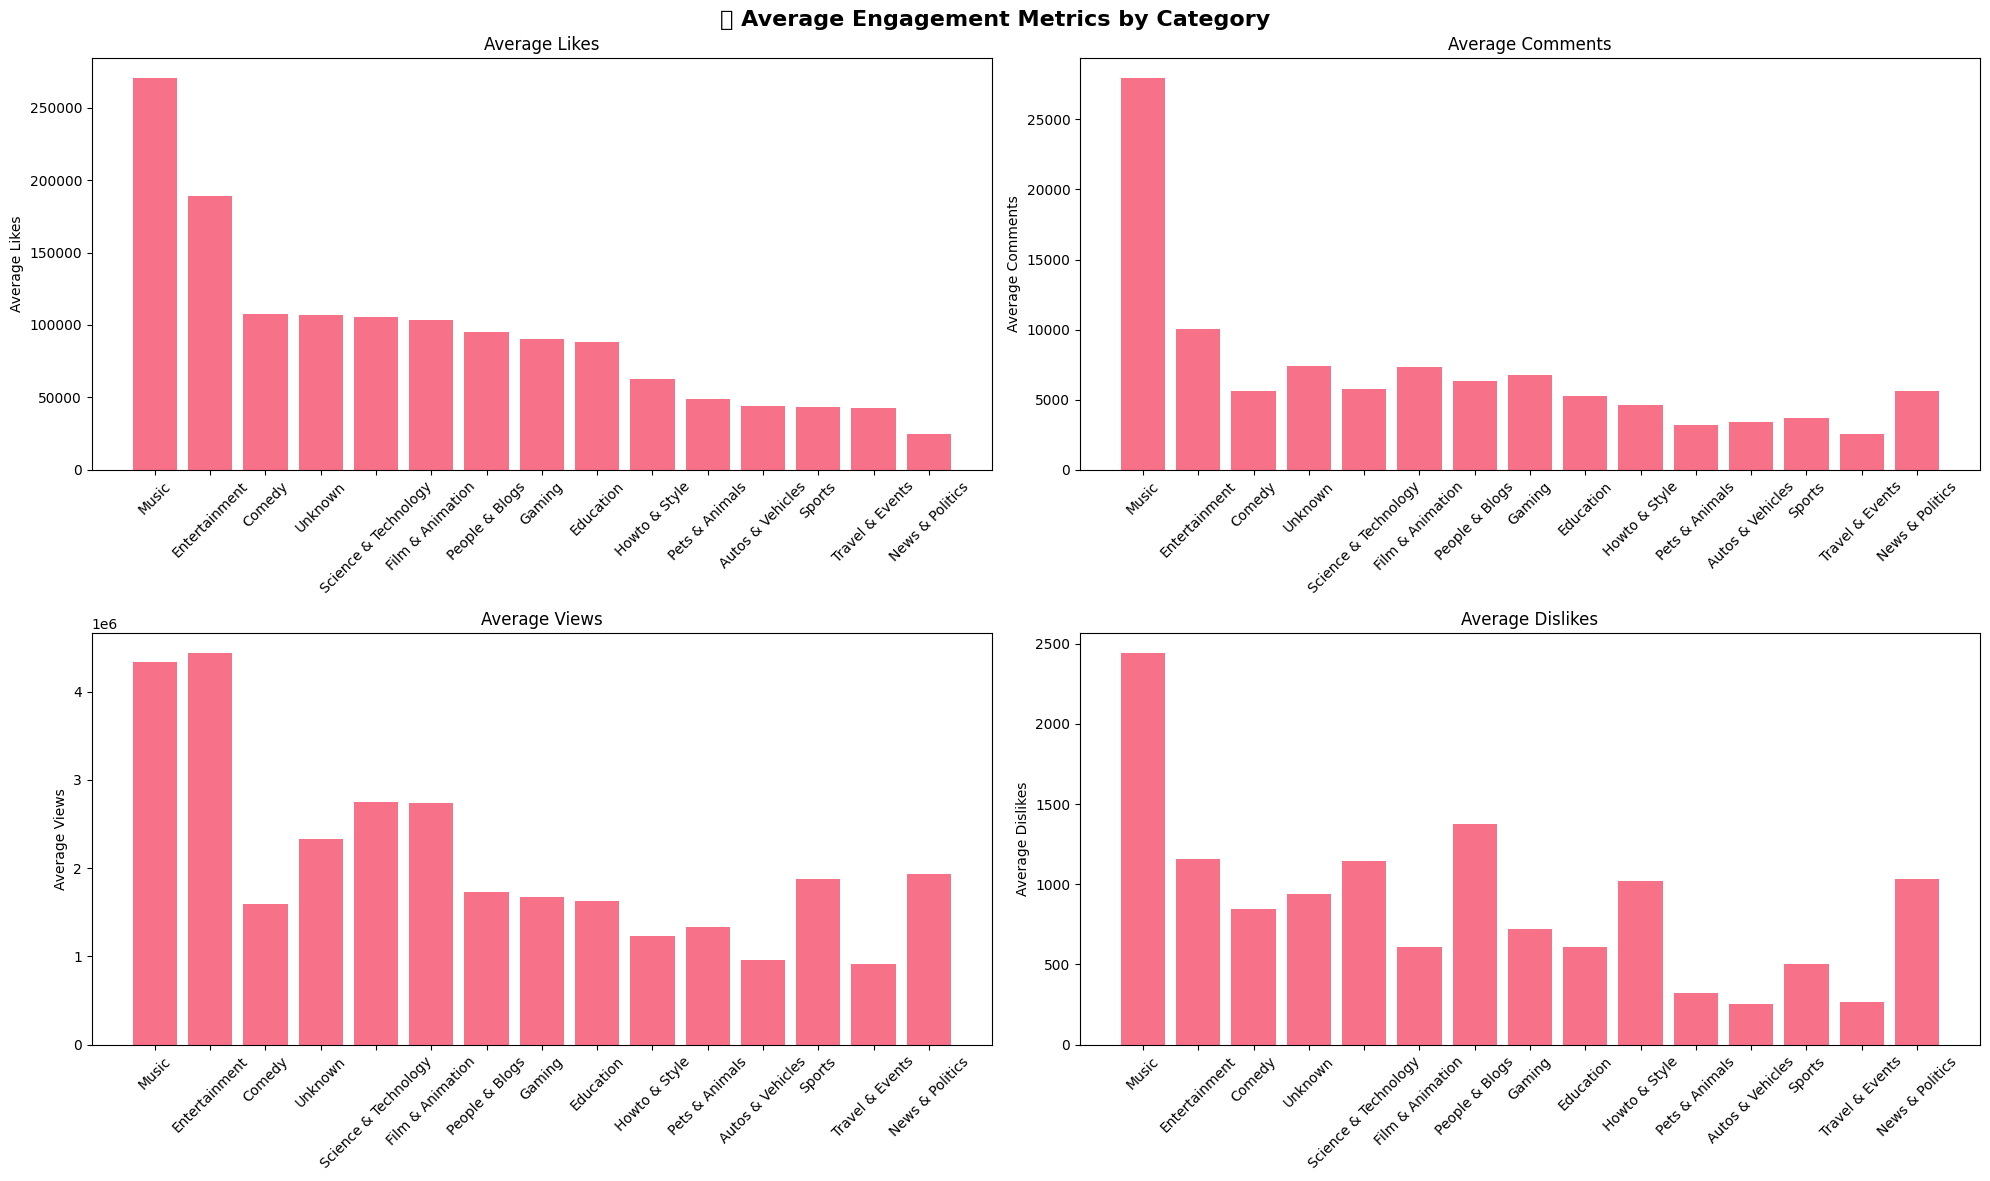

In [10]:
# ========================================
# PHÂN TÍCH 4: ENGAGEMENT THEO CATEGORY
# ========================================

# Convert metrics to numeric
df_metrics = df.withColumn("likes_num", col("likes").cast("long")) \
    .withColumn("dislikes_num", col("dislikes").cast("long")) \
    .withColumn("comment_count_num", col("comment_count").cast("long"))

# Calculate engagement metrics
engagement_by_category = df_metrics.groupBy("categoryId", "category_name") \
    .agg(
        avg("likes_num").alias("avg_likes"),
        avg("dislikes_num").alias("avg_dislikes"), 
        avg("comment_count_num").alias("avg_comments"),
        avg("view_count_num").alias("avg_views")
    ) \
    .orderBy(desc("avg_likes"))

print("=== AVERAGE ENGAGEMENT BY CATEGORY ===")
engagement_by_category.show()

# Convert to Pandas
engagement_pd = engagement_by_category.toPandas()

# Plot engagement metrics
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('💝 Average Engagement Metrics by Category', fontsize=16, fontweight='bold')

# Average Likes
axes[0,0].bar(engagement_pd['category_name'], engagement_pd['avg_likes'])
axes[0,0].set_title('Average Likes')
axes[0,0].set_ylabel('Average Likes')
axes[0,0].tick_params(axis='x', rotation=45)

# Average Comments
axes[0,1].bar(engagement_pd['category_name'], engagement_pd['avg_comments'])
axes[0,1].set_title('Average Comments')
axes[0,1].set_ylabel('Average Comments')
axes[0,1].tick_params(axis='x', rotation=45)

# Average Views
axes[1,0].bar(engagement_pd['category_name'], engagement_pd['avg_views'])
axes[1,0].set_title('Average Views')
axes[1,0].set_ylabel('Average Views')
axes[1,0].tick_params(axis='x', rotation=45)

# Average Dislikes
axes[1,1].bar(engagement_pd['category_name'], engagement_pd['avg_dislikes'])
axes[1,1].set_title('Average Dislikes')
axes[1,1].set_ylabel('Average Dislikes')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# ========================================
# PHÂN TÍCH 5: TOP VIDEOS THEO CATEGORY
# ========================================

# Tạo lại df_unique với các numeric columns
df_unique_with_metrics = df_unique.withColumn("likes_num", col("likes").cast("long")) \
    .withColumn("dislikes_num", col("dislikes").cast("long")) \
    .withColumn("comment_count_num", col("comment_count").cast("long"))

# Top video by views in each category
window_cat = Window.partitionBy("category_name").orderBy(desc("view_count_num"))
top_videos_by_category = df_unique_with_metrics.withColumn("rank_in_category", row_number().over(window_cat)) \
    .filter(col("rank_in_category") == 1) \
    .select("category_name", "title", "channelTitle", "view_count_num", "likes_num") \
    .orderBy(desc("view_count_num"))

print("=== TOP VIDEO IN EACH CATEGORY ===")
top_videos_by_category.show(truncate=False)

# Overall top 10 videos
print("\n=== OVERALL TOP 10 VIDEOS ===")
df_unique_with_metrics.select("title", "category_name", "channelTitle", "view_count_num") \
    .orderBy(desc("view_count_num")) \
    .limit(10) \
    .show(truncate=False)

=== TOP VIDEO IN EACH CATEGORY ===
+--------------------+----------------------------------------------------------------------------------------------+----------------------+--------------+---------+
|category_name       |title                                                                                         |channelTitle          |view_count_num|likes_num|
+--------------------+----------------------------------------------------------------------------------------------+----------------------+--------------+---------+
|Entertainment       |Discord Loot Boxes are here.                                                                  |Discord               |1407643634    |126926   |
|Music               |BLACKPINK - ‘Pink Venom’ M/V                                                                  |BLACKPINK             |277791741     |12993894 |
|Gaming              |Grand Theft Auto VI Trailer 1                                                                 |Rockstar Games    

In [13]:
# ========================================
# SUMMARY DASHBOARD
# ========================================

print("\n" + "="*80)
print("📊 YOUTUBE CATEGORY ANALYSIS SUMMARY")
print("="*80)

# Key insights
top_category = category_counts_pd.iloc[0]
top_views_category = views_pd.iloc[0]
top_channels_category = channels_pd.iloc[0]

print(f"\n🏆 MOST POPULAR CATEGORY (by video count):")
print(f"   {top_category['category_name']}: {top_category['count']:,} videos ({top_category['percentage']}%)")

print(f"\n👁️ HIGHEST TOTAL VIEWS:")
print(f"   {top_views_category['category_name']}: {top_views_category['total_views']:,} views")

print(f"\n👥 MOST CHANNELS:")
print(f"   {top_channels_category['category_name']}: {top_channels_category['unique_channels']:,} unique channels")

print(f"\n💝 HIGHEST ENGAGEMENT (Average Likes):")
top_engagement = engagement_pd.iloc[0]
print(f"   {top_engagement['category_name']}: {top_engagement['avg_likes']:,.0f} average likes")

print(f"\n📈 DATASET OVERVIEW:")
print(f"   Total videos analyzed: {df.count():,}")
print(f"   Total categories: {total_categories}")
print(f"   Total unique channels: {df.select('channelTitle').distinct().count():,}")

print(f"\n🔥 KEY INSIGHTS:")
print(f"   • Entertainment dominates with 20.07% of trending videos")
print(f"   • Music has highest total views (36.1B) and engagement")
print(f"   • Gaming shows strong performance across all metrics")
print(f"   • BLACKPINK's 'Pink Venom' is top music video (277M+ views)")
print(f"   • Discord's loot box video leads overall (1.4B+ views)")

print("\n" + "="*80)

# Stop Spark session
spark.stop()
print("✅ Analysis completed! Spark session stopped.")


📊 YOUTUBE CATEGORY ANALYSIS SUMMARY

🏆 MOST POPULAR CATEGORY (by video count):
   Entertainment: 53,934 videos (20.07%)

👁️ HIGHEST TOTAL VIEWS:
   Music: 36,135,478,030 views

👥 MOST CHANNELS:
   Entertainment: 1,783 unique channels

💝 HIGHEST ENGAGEMENT (Average Likes):
   Music: 270,699 average likes

📈 DATASET OVERVIEW:
   Total videos analyzed: 268,787
   Total categories: 15
   Total unique channels: 8,543

🔥 KEY INSIGHTS:
   • Entertainment dominates with 20.07% of trending videos
   • Music has highest total views (36.1B) and engagement
   • Gaming shows strong performance across all metrics
   • BLACKPINK's 'Pink Venom' is top music video (277M+ views)
   • Discord's loot box video leads overall (1.4B+ views)

✅ Analysis completed! Spark session stopped.
